In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Load artifacts exported from 01_data_exploration.ipynb ---
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "NK_cell_dataset").exists():
            return candidate
    raise FileNotFoundError("Projektstamm konnte nicht gefunden werden.")

PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_DIR = PROJECT_ROOT

nk_balanced_raw = pd.read_parquet(ARTIFACT_DIR / "nk_balanced_raw.parquet")
channel_table = pd.read_parquet(ARTIFACT_DIR / "channel_table.parquet")
labels = pd.read_csv(ARTIFACT_DIR / "labels.csv")

# --- Filter to analysis markers only ---
analysis_markers = channel_table.loc[channel_table["analysis_marker"], "marker_name_pns"].tolist()
meta_cols = ["sample_id", "label", "clinical_group"]
nk_filtered = nk_balanced_raw[meta_cols + analysis_markers].copy()

print(f"Loaded {len(nk_filtered):,} cells × {len(analysis_markers)} markers "
      f"from {nk_filtered['sample_id'].nunique()} donors")

Loaded 40,000 cells × 37 markers from 20 donors


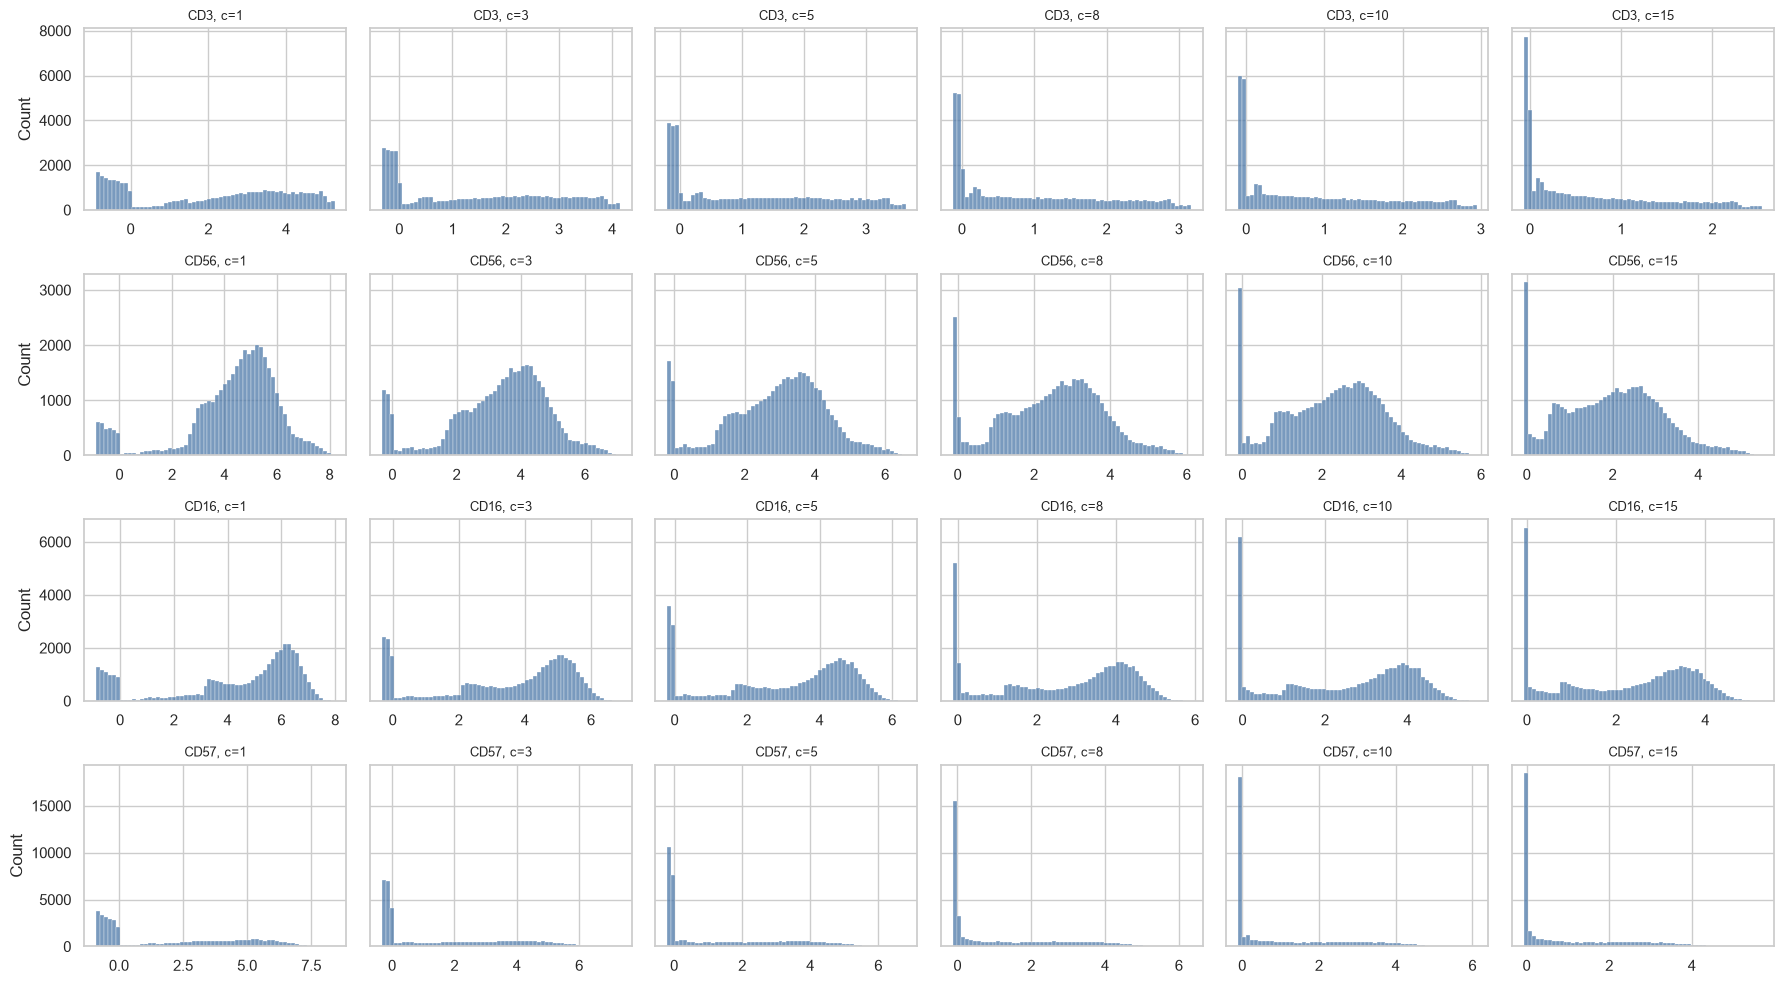

In [4]:
# --- arcsinh cofactor exploration ---
def arcsinh_transform(frame, marker_names, cofactor):
    out = frame.copy()
    out[marker_names] = np.arcsinh(out[marker_names] / cofactor)
    return out

cofactor_candidates = [1, 3, 5, 8, 10, 15]
diagnostic_markers = ["CD3", "CD56", "CD16", "CD57"]  # known bimodal markers

fig, axes = plt.subplots(len(diagnostic_markers), len(cofactor_candidates),
                          figsize=(3 * len(cofactor_candidates), 2.5 * len(diagnostic_markers)),
                          sharey="row")

for row, marker in enumerate(diagnostic_markers):
    for col, cofactor in enumerate(cofactor_candidates):
        transformed = np.arcsinh(nk_filtered[marker] / cofactor)
        sns.histplot(transformed, bins=60, ax=axes[row, col], color="#4c78a8")
        axes[row, col].set_title(f"{marker}, c={cofactor}", fontsize=9)
        axes[row, col].set_xlabel("")

plt.tight_layout()
plt.show()

In [5]:
# --- Apply chosen cofactor + z-score for PCA/t-SNE/UMAP input ---
ARCSINH_COFACTOR = 5.0

nk_transformed = arcsinh_transform(nk_filtered, analysis_markers, ARCSINH_COFACTOR)

# --- Z-score normalization ---
scaler = StandardScaler()
nk_scaled = nk_transformed.copy()
nk_scaled[analysis_markers] = scaler.fit_transform(nk_transformed[analysis_markers])

# Prepare the feature matrix for downstream analysis
X = nk_scaled[analysis_markers].to_numpy()
sample_ids = nk_scaled["sample_id"].to_numpy()
clinical_group = nk_scaled["clinical_group"].to_numpy()

print(f"Feature matrix ready: X.shape = {X.shape}")
display(nk_scaled.head())

Feature matrix ready: X.shape = (40000, 37)


,sample_id,label,clinical_group,CD3,CD27,CD19,CD4,CD8,CD57,2DL1-S1,...,CD94,CD34,CCR7,2DL3,NKG2A,HLA-DR,2DL4,CD56,2DL5,CD25
0,a_001,1,CMV+,-0.970905,-0.606723,-0.603757,-0.518787,0.408722,1.262401,-0.637691,...,-0.660154,-0.590707,-0.278266,-0.601411,0.823392,0.193011,1.498108,-0.237036,-0.737142,-0.253715
1,a_001,1,CMV+,0.380514,-0.765951,-0.537882,-0.469332,-0.665763,-0.869966,0.252270,...,-1.368312,-0.683341,-0.356010,2.327783,-0.991975,0.312983,-0.194853,-0.329703,-0.687247,-0.474097
2,a_001,1,CMV+,-0.742688,0.897181,0.694621,-0.482967,0.630869,1.184771,-0.675650,...,-1.012467,-0.719988,-0.497955,-0.539528,-0.747228,-1.364530,-0.724681,0.127341,-0.538723,-0.559586
3,a_001,1,CMV+,-0.518125,-0.620518,-0.494963,-0.552950,0.128876,-0.877883,-0.632458,...,0.925268,-0.523634,-0.426150,0.670718,1.328362,0.174369,-0.761817,-1.051555,-0.613813,-0.433535
4,a_001,1,CMV+,-0.998702,1.391164,-0.127265,-0.264165,-0.761708,1.263926,0.287416,...,-0.194036,0.457053,1.736379,-0.479299,0.630355,0.818920,-0.536806,-1.076981,-0.198778,-0.189867


# PCA

In [6]:
# --- PCA on arcsinh + z-scored data ---
N_PCS = 20  # revisit via explained-variance elbow

pca = PCA(n_components=N_PCS, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X).astype(np.float32, copy=False)  # X from previous step: arcsinh(c=5) + z-scored

print(f"Explained variance (first {N_PCS} PCs): {pca.explained_variance_ratio_.sum():.2%}")


Explained variance (first 20 PCs): 75.72%


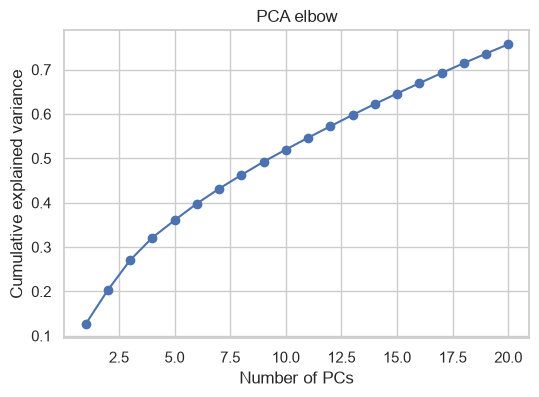

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, N_PCS + 1), np.cumsum(pca.explained_variance_ratio_), marker="o")
ax.set(xlabel="Number of PCs", ylabel="Cumulative explained variance", title="PCA elbow")
plt.show()


# t-SNE

In [8]:
# --- Feed PCA output into t-SNE and UMAP instead of the raw 37-dim matrix ---
#tsne = TSNE(
#    perplexity=30, initialization="pca", random_state=RANDOM_SEED,
#)
#X_tsne = tsne.fit(X_pca)

# UMAP

UMAP completed for 10,000 of 40,000 cells


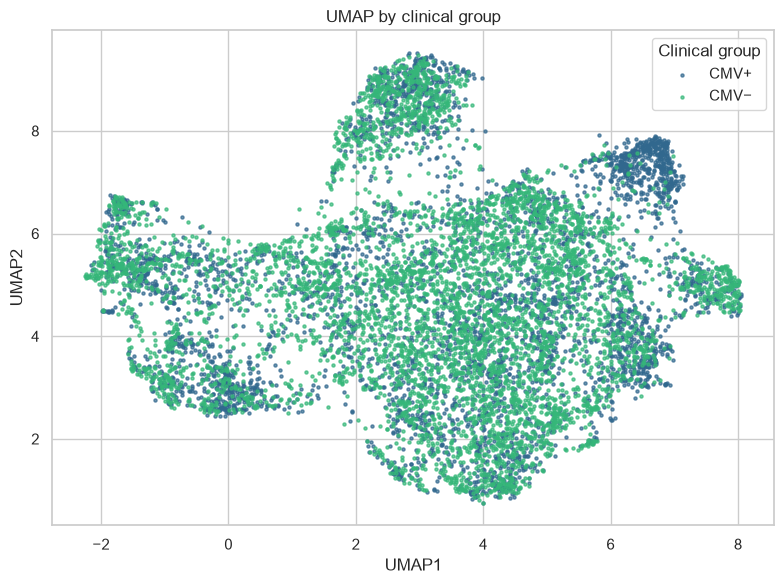

In [22]:
# UMAP's nearest-neighbor index can crash the Windows kernel on the full table.
# Use a bounded float32 input for a stable exploratory embedding.
UMAP_MAX_CELLS = 10000
umap_rng = np.random.default_rng(RANDOM_SEED)
umap_indices = np.sort(
    umap_rng.choice(len(X_pca), size=min(UMAP_MAX_CELLS, len(X_pca)), replace=False)
)
X_umap_input = X_pca[umap_indices]

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_SEED,
    n_jobs=1,
    low_memory=True,
)
X_umap = reducer.fit_transform(X_umap_input)
print(f"UMAP completed for {len(umap_indices):,} of {len(X_pca):,} cells")

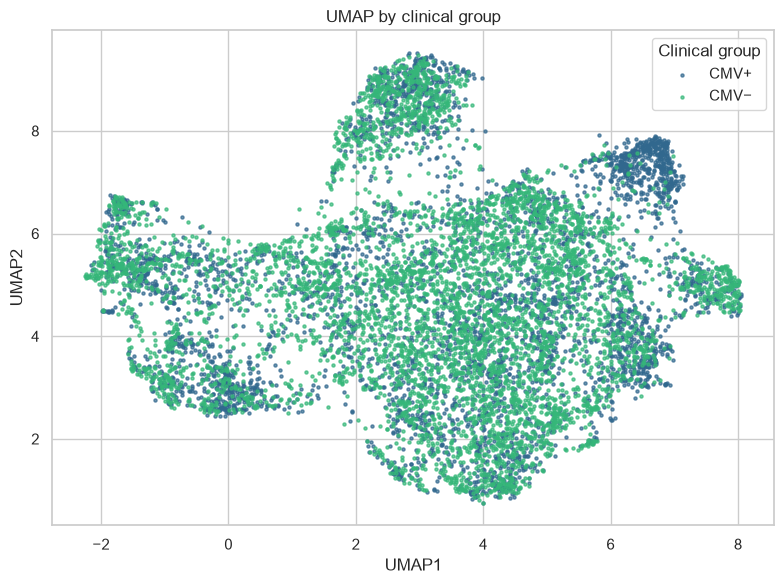

In [23]:
# Plot categorical clinical groups with explicit colors.
plt.figure(figsize=(8, 6))
clinical_group_umap = clinical_group[umap_indices]
clinical_categories = pd.unique(clinical_group_umap)
clinical_colors = dict(zip(clinical_categories, sns.color_palette("viridis", len(clinical_categories))))
for group in clinical_categories:
    group_mask = clinical_group_umap == group
    plt.scatter(
        X_umap[group_mask, 0],
        X_umap[group_mask, 1],
        color=clinical_colors[group],
        label=group,
        s=5,
        alpha=0.7,
    )
plt.title("UMAP by clinical group")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Clinical group")
plt.tight_layout()
plt.show()

In [10]:
import anndata as ad
import scanpy as sc

sc.settings.verbosity = 1

# nk_transformed = arcsinh(c=5)-transformed data from the previous step, NOT yet z-scored
obs = nk_transformed[["sample_id", "label", "clinical_group"]].reset_index(drop=True)
X_arcsinh = nk_transformed[analysis_markers].to_numpy()

adata = ad.AnnData(
    X=X_arcsinh,
    obs=obs,
    var=pd.DataFrame(index=analysis_markers),
)
adata.layers["arcsinh"] = adata.X.copy()  # keep a snapshot before scaling

print(adata)

AnnData object with n_obs × n_vars = 40000 × 37
    obs: 'sample_id', 'label', 'clinical_group'
    layers: None (.X), 'arcsinh'


c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


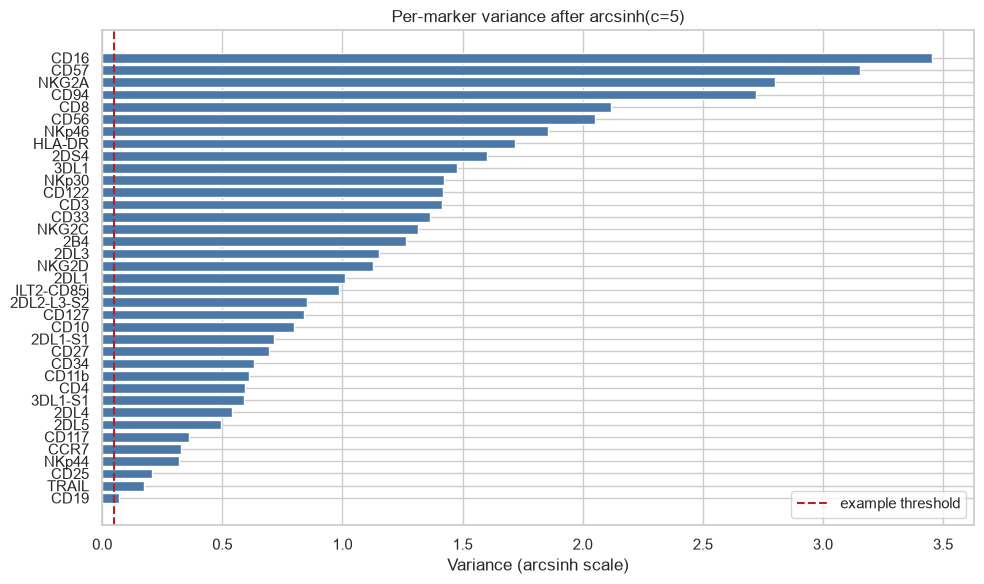

,variance
CD19,0.070028
TRAIL,0.173690
CD25,0.209308
NKp44,0.320738
CCR7,0.328321
CD117,0.360785
2DL5,0.495571
2DL4,0.541105
3DL1-S1,0.588375
CD4,0.594914


In [11]:
# Detecting and filtering near-zero-variance markers
marker_variance = pd.Series(
    adata.layers["arcsinh"].var(axis=0), index=adata.var_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(marker_variance.index, marker_variance.values, color="#4c78a8")
ax.axvline(0.05, color="firebrick", linestyle="--", label="example threshold")
ax.set(xlabel="Variance (arcsinh scale)", title="Per-marker variance after arcsinh(c=5)")
ax.legend()
plt.tight_layout()
plt.show()

marker_variance.to_frame("variance")

In [12]:
LOW_VARIANCE_THRESHOLD = 0.05  # inspect the plot and adjust

low_variance_markers = marker_variance[marker_variance < LOW_VARIANCE_THRESHOLD].index.tolist()
print(f"Flagged as low-variance ({len(low_variance_markers)}): {low_variance_markers}")

# Only drop after checking these aren't biologically meaningful "always-on/off" markers
kept_markers = [m for m in analysis_markers if m not in low_variance_markers]
adata = adata[:, kept_markers].copy()
print(f"Retained {adata.n_vars} markers for PCA")

Flagged as low-variance (0): []
Retained 37 markers for PCA


In [13]:
# sc.pp.scale z-scores each marker (mean 0, unit variance) and stores mean/std in adata.var
sc.pp.scale(adata, max_value=None)  # set e.g. max_value=10 if you want outlier clipping
adata.layers["scaled"] = adata.X.copy()

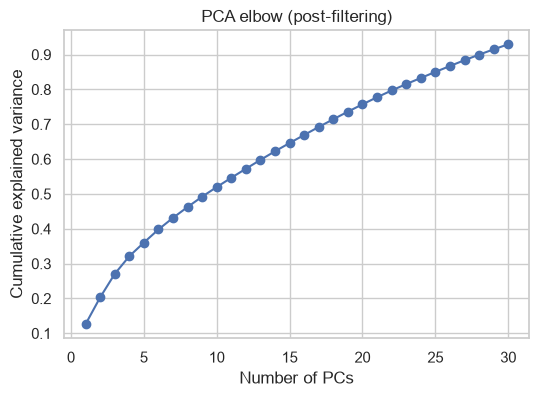

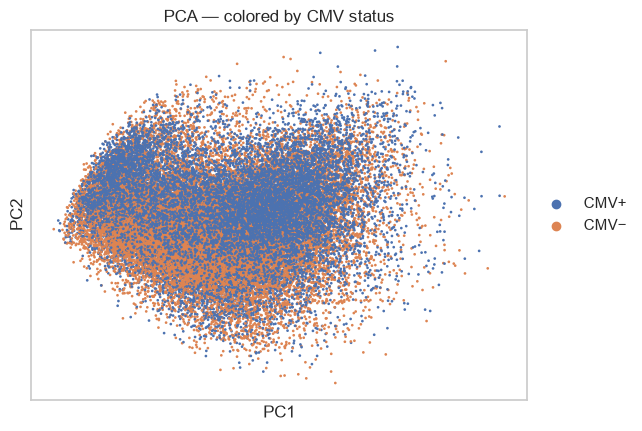

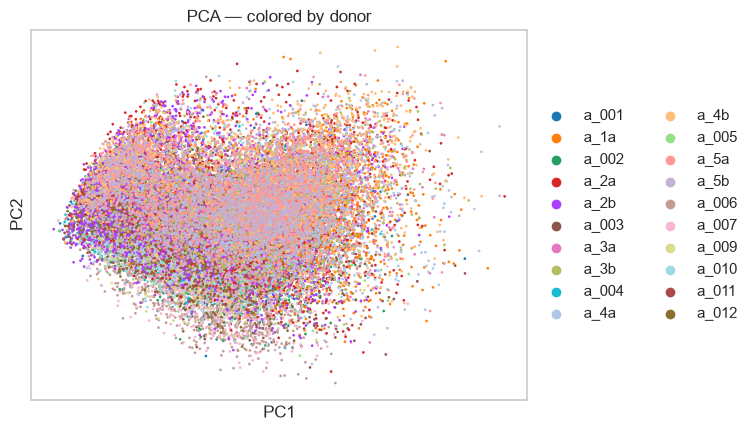

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


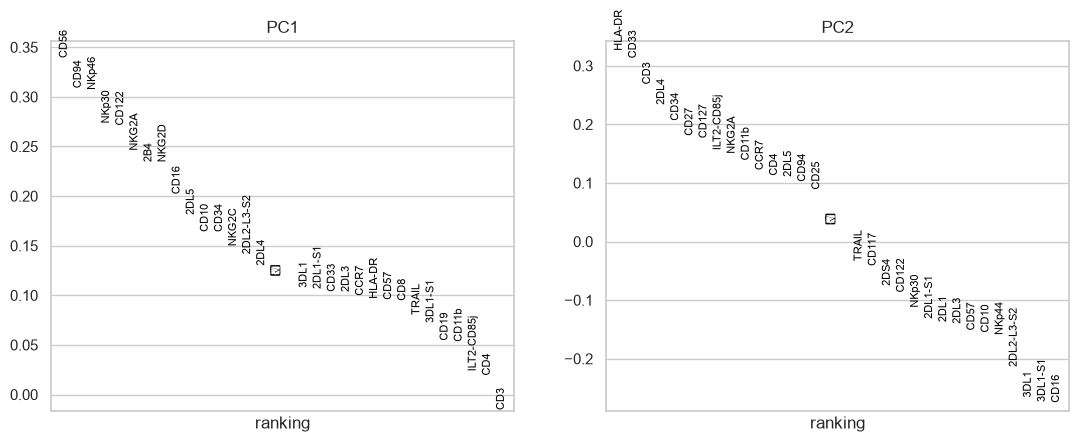

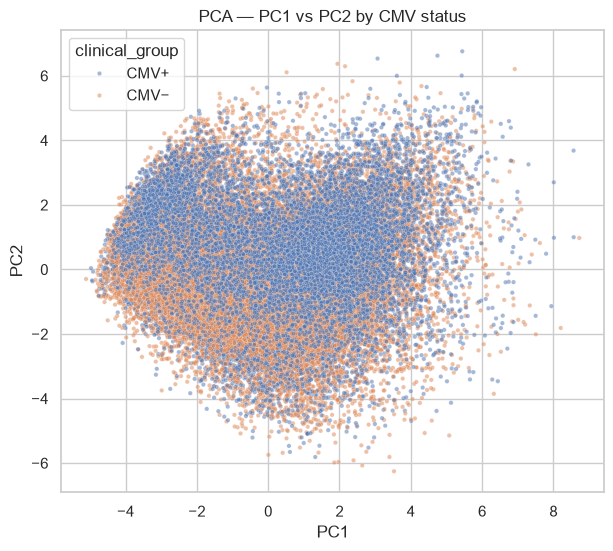

In [14]:
sc.tl.pca(adata, n_comps=30, svd_solver="arpack", random_state=RANDOM_SEED)

# Re-plot the elbow now that noisy markers are removed
cumulative_var = np.cumsum(adata.uns["pca"]["variance_ratio"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(cumulative_var) + 1), cumulative_var, marker="o")
ax.set(xlabel="Number of PCs", ylabel="Cumulative explained variance", title="PCA elbow (post-filtering)")
plt.show()

# Colored by CMV clinical group
sc.pl.pca(
    adata, color="clinical_group", dimensions=(0, 1),
    title="PCA — colored by CMV status", size=15,
)

# Colored by donor, to check for donor-driven structure/batch effects
sc.pl.pca(
    adata, color="sample_id", dimensions=(0, 1),
    title="PCA — colored by donor", size=15,
)

# Per-marker loadings on the first two PCs — useful for interpreting what PC1/PC2 represent
sc.pl.pca_loadings(adata, components=[1, 2])

# Manual scatter, if you want more control than sc.pl.pca gives you
import seaborn as sns

pca_df = pd.DataFrame(adata.obsm["X_pca"][:, :2], columns=["PC1", "PC2"])
pca_df["clinical_group"] = adata.obs["clinical_group"].values
pca_df["sample_id"] = adata.obs["sample_id"].values

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="clinical_group", alpha=0.5, s=10, ax=ax)
ax.set_title("PCA — PC1 vs PC2 by CMV status")
plt.show()

In [ ]:
# --- One fixed subsample, shared across PCA / t-SNE / UMAP for fair comparison ---
COMPARISON_N_CELLS = 10_000
compare_rng = np.random.default_rng(RANDOM_SEED)
compare_idx = np.sort(compare_rng.choice(len(X_pca), size=COMPARISON_N_CELLS, replace=False))

X_pca_cmp = X_pca[compare_idx]
sample_ids_cmp = sample_ids[compare_idx]
clinical_group_cmp = clinical_group[compare_idx]

print(f"Using {COMPARISON_N_CELLS:,} cells (fixed subsample) for all three embeddings")

Using 10,000 cells (fixed subsample) for all three embeddings


In [ ]:
# --- t-SNE on the same fixed subsample ---
# scikit-learn's Barnes-Hut implementation avoids the native openTSNE crash here.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=RANDOM_SEED,
    n_jobs=1,
    max_iter=750,
    method="barnes_hut",
)
X_tsne_cmp = tsne.fit_transform(X_pca_cmp)
print(f"t-SNE completed for {len(X_pca_cmp):,} cells")

: 

In [ ]:
# --- UMAP on the same fixed subsample ---
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_SEED,
    low_memory=True,
)
X_umap_cmp = reducer.fit_transform(X_pca_cmp)

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


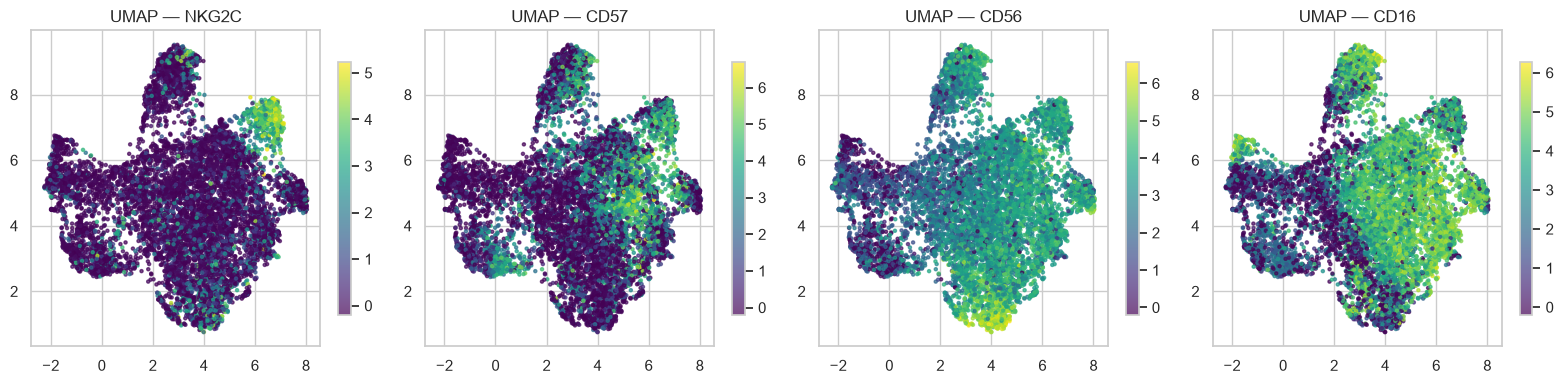

In [18]:
# --- Marker-overlay plots: check for the rare CMV-associated subset directly ---
# Instead of only coloring by CMV/donor, color the embedding by continuous marker
# expression — a rare subset may only show up this way, not as a global split.
diagnostic_markers_for_overlay = ["NKG2C", "CD57", "CD56", "CD16"]

# Pull the arcsinh-transformed (unscaled) marker values for the same subsampled cells,
# so color scales stay interpretable (rather than z-scored units).
marker_values_cmp = nk_transformed.iloc[compare_idx][diagnostic_markers_for_overlay]

def plot_embedding_by_markers(coords, title_prefix):
    fig, axes = plt.subplots(1, len(diagnostic_markers_for_overlay),
                              figsize=(4 * len(diagnostic_markers_for_overlay), 4))
    for ax, marker in zip(axes, diagnostic_markers_for_overlay):
        sc_plot = ax.scatter(
            coords[:, 0], coords[:, 1],
            c=marker_values_cmp[marker], cmap="viridis", s=5, alpha=0.7,
        )
        ax.set_title(f"{title_prefix} — {marker}")
        fig.colorbar(sc_plot, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

plot_embedding_by_markers(X_umap_cmp, "UMAP")
#plot_embedding_by_markers(np.asarray(X_tsne_cmp), "t-SNE")

In [ ]:
# --- Persist all three embeddings + metadata for the next notebook (e.g. clustering) ---
embedding_export = pd.DataFrame({
    "sample_id": sample_ids_cmp,
    "clinical_group": clinical_group_cmp,
    "PC1": X_pca_cmp[:, 0], "PC2": X_pca_cmp[:, 1],
    "tsne1": X_tsne_cmp[:, 0], "tsne2": X_tsne_cmp[:, 1],
    "umap1": X_umap_cmp[:, 0], "umap2": X_umap_cmp[:, 1],
})
embedding_export.to_parquet(ARTIFACT_DIR / "embeddings_comparison_subsample.parquet", index=False)

# Also persist the full-data PCA (all 40k cells) separately, for anything downstream
# that doesn't need the fixed subsample (e.g. clustering on the full dataset)
np.save(ARTIFACT_DIR / "X_pca_full.npy", X_pca)
nk_transformed[["sample_id", "label", "clinical_group"]].to_parquet(
    ARTIFACT_DIR / "nk_transformed_meta.parquet", index=False
)